<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase2/assignmet4/Week_7_Clustering_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [3]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [5]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print("shape",df.shape)

# Print dtypes
print("dtypes",df.dtypes)

# Print first 5 rows
print("first 5 rows",df.head(5))

# Check missing values — which columns have nulls? How many?
print('missing values', df.isnull().sum())

# Print basic descriptive statistics
print("description", df.describe())

shape (541910, 8)
dtypes Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object
first 5 rows   Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  Unit

**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

_Write here before moving on._


Here’s a concise version:

* **Size:** 541,910 rows × 8 columns
* **Unit of row:** Each row is a single product line item in a transaction (invoice-level detail)

### Useful columns for customer analysis

* **Invoice:** transaction frequency
* **Quantity & Price:** total spend calculation
* **InvoiceDate:** recency (RFM analysis)
* **Customer ID:** primary customer identifier
* **Country:** geographic segmentation
* **Description & StockCode:** optional product insights/segmentation

### Key issues

* **Missing data:**

  * Customer ID: 135,080 missing (critical issue)
  * Description: 1,454 missing
* **Data anomalies:**

  * Negative Quantity → returns/cancellations
  * Negative Price → likely errors or credit adjustments
* **Invoice codes:** 'C' invoices likely represent cancellations
* **Data types:**

  * Customer ID is float due to NaNs (needs cleanup)
  * InvoiceDate is correctly formatted as datetime


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [7]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# Why? CustomerID is crucial for customer segmentation. Rows without a CustomerID
# cannot be assigned to a unique customer, making them unusable for this analysis.
# We are dropping these rows because we cannot infer customer identity for them.
original_rows_step1 = df_clean.shape[0]
df_clean.dropna(subset=['Customer ID'], inplace=True)
rows_lost_step1 = original_rows_step1 - df_clean.shape[0]
print(f"Rows lost after dropping missing CustomerIDs: {rows_lost_step1}")


# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Cancelled invoices start with 'C'
# Why remove them? Keeping them would skew frequency and monetary calculations,
# as they represent reversed transactions, not actual purchases. For monetary,
# they would either reduce total spend or introduce negative values depending
# on how they are handled, which is not representative of customer purchasing power.
original_rows_step2 = df_clean.shape[0]
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
rows_lost_step2 = original_rows_step2 - df_clean.shape[0]
print(f"Rows lost after dropping cancelled transactions: {rows_lost_step2}")

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Why? Negative quantities (after removing 'C' invoices) and prices are likely
# data entry errors or specific credit adjustments that don't represent a purchase.
# They would distort total spend calculations and average basket sizes.
original_rows_step3 = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
rows_lost_step3 = original_rows_step3 - df_clean.shape[0]
print(f"Rows lost after dropping negative Quantity/Price: {rows_lost_step3}")

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Why? To enable time-based calculations like recency, it's essential to have
# InvoiceDate in a proper datetime format. The initial inspection showed it was
# already datetime64[ns], but this step ensures consistency and handles any potential
# parsing issues if the dtype was object/string (though not in this dataset initially).
# No rows are lost in this step, as it's a type conversion.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice = Quantity * Price
# Why? This is the fundamental value representing the monetary contribution of each line item.
# It's essential for calculating total customer spend.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f"\nOriginal shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]}")

Rows lost after dropping missing CustomerIDs: 135080
Rows lost after dropping cancelled transactions: 8905
Rows lost after dropping negative Quantity/Price: 40

Original shape: (541910, 8)
Clean shape: (397885, 9)
Total rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [8]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose a reference date for Recency calculation
# Why this date? Using the day after the last transaction ensures that all
# recency values are positive and meaningful, representing days *since* activity.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency: {reference_date}")

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
# This feature measures how recently a customer made a purchase. It captures
# their current engagement level. Customers with lower recency are generally
# more engaged and responsive to marketing.
# Limitation: It doesn't capture the frequency of their recent purchases, only the last one.
recency_df = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['InvoiceDate']).dt.days

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer
# This feature measures how often a customer purchases. It captures their
# loyalty and purchasing habits. Higher frequency customers are often more loyal.
# Limitation: It doesn't differentiate between small and large purchases, only transaction count.
frequency_df = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency_df.rename(columns={'Invoice': 'Frequency'}, inplace=True)

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer
# This feature measures the total amount of money a customer has spent. It captures
# their financial value to the business. Higher monetary customers are typically
# the most valuable.
# Limitation: Can be heavily skewed by a few high-value purchases.
monetary_df = df_clean.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary_df.rename(columns={'TotalPrice': 'Monetary'}, inplace=True)

# ── Combine into customer matrix ─────────────────────────────────────────────
# customer_df should have columns: CustomerID, Recency, Frequency, Monetary
# (+ any extra features you engineered)
customer_df = recency_df[['Customer ID', 'Recency']]
customer_df = customer_df.merge(frequency_df, on='Customer ID')
customer_df = customer_df.merge(monetary_df, on='Customer ID')

# Sanity check
print(f"\nCustomer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.\n")
display(customer_df.head())

Reference Date for Recency: 2011-12-10 12:50:00

Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.



,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


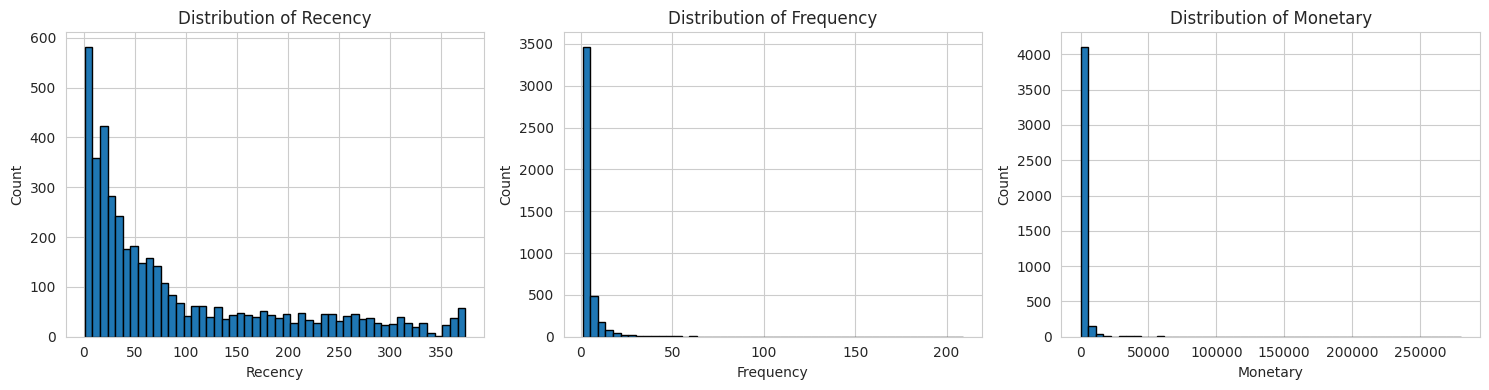

In [9]:
# ── Distribution Plots ───────────────────────────────────────────────────────
# Plot the distribution of each feature BEFORE handling outliers
# What do you observe? Are there extreme values?

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# What do you see in these distributions?
# Are there outliers? How will they affect clustering?

# Observations:
# - Recency: The distribution is right-skewed, with a large number of customers having low recency (purchased recently)
#  and a long tail of customers with high recency (purchased a long time ago). There are some extreme outliers with very high recency values.
# - Frequency: The distribution is highly right-skewed, with most customers having very low frequency (1 or a few purchases) and a few customers with very high frequency. This indicates significant outliers on the higher end.
# - Monetary: Similar to Frequency, the Monetary distribution is also highly right-skewed. Most customers have spent relatively small amounts, while a small number of customers are high-spenders, creating extreme outliers.
# These outliers, particularly in Frequency and Monetary, will heavily influence clustering algorithms like K-Means which rely on distance metrics, potentially distorting cluster centroids and making it difficult to form meaningful clusters. Preprocessing such as capping or transformation (e.g., log transformation) will be necessary.

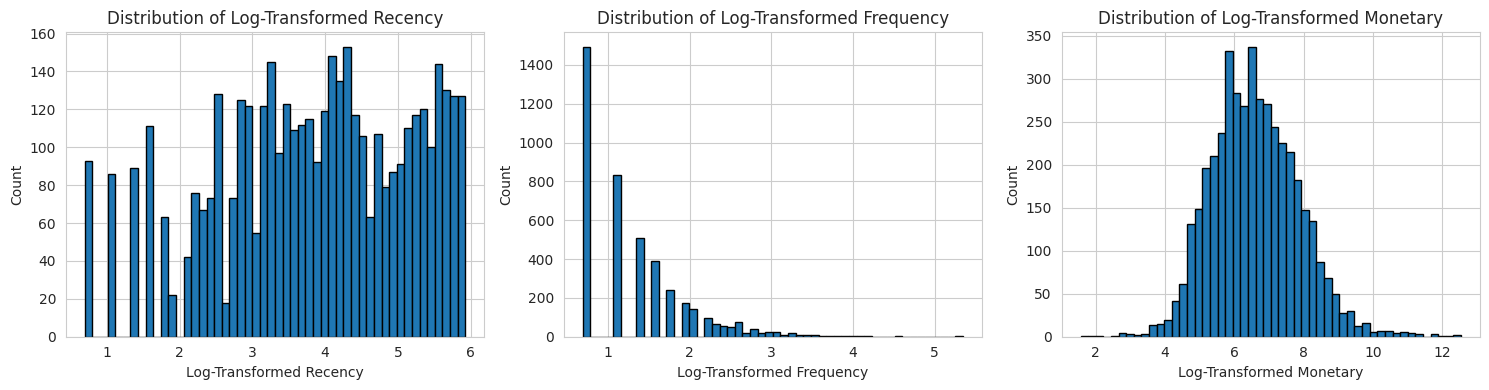

In [10]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Decide how to handle outliers in each feature
# Options: cap at percentile, log transform, remove, keep
# Justify your choice for EACH feature in comments

# Given the highly skewed distributions and the presence of extreme outliers,
# a log transformation is a suitable approach. It reduces the impact of extreme
# values and makes the distributions more symmetrical, which is beneficial for
# distance-based clustering algorithms like K-Means.
# We will add 1 to the values before taking the log to handle zero values gracefully,
# especially for Frequency and Monetary if any customer had 0 (though our cleaning ensures >0).

# We will create a new DataFrame for the transformed features.
X = customer_df[['Recency', 'Frequency', 'Monetary']].copy()

# Apply log transformation (log1p to handle potential zero values if they existed, though not strictly necessary here)
X['Recency'] = np.log1p(X['Recency'])
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary'] = np.log1p(X['Monetary'])

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features_transformed = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features_transformed):
    axes[i].hist(X[feat], bins=50, edgecolor='k')
    axes[i].set_title(f'Distribution of Log-Transformed {feat}')
    axes[i].set_xlabel(f'Log-Transformed {feat}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment after the plots):
# Compare the original vs. transformed distributions. How do they look now?
# Observations after log transformation:
# - Recency: The log-transformed Recency distribution now appears more centralized and less skewed, though still slightly right-skewed. The extreme outliers are much less prominent.
# - Frequency: The log-transformed Frequency distribution is much more normalized, resembling a more Gaussian-like shape. The extreme skewness has been significantly reduced.
# - Monetary: Similarly, the log-transformed Monetary distribution is also much closer to a normal distribution, with the impact of high-spending outliers greatly diminished.
# The log transformation has successfully compressed the range of these variables, making them more amenable to clustering algorithms that assume spherical or equally weighted features.

In [11]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? Answer in a comment before scaling.
# Scaling is necessary for clustering algorithms like K-Means because they rely on
# distance calculations. If features have different scales or units, the feature
# with the largest values will have a disproportionately high influence on the
# distance metric, effectively dominating the clustering process. Standardization
# (using StandardScaler) transforms the data to have a mean of 0 and a standard
# deviation of 1, ensuring all features contribute equally to the distance calculation.

# Apply StandardScaler
sis = StandardScaler()

# Fit and transform your feature matrix
X_scaled = sis.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Verify scaling worked
print("\nMean of scaled features:")
print(X_scaled_df.mean().round(2))
print("\nStandard deviation of scaled features:")
print(X_scaled_df.std().round(2))


Mean of scaled features:
Recency     -0.0
Frequency   -0.0
Monetary     0.0
dtype: float64

Standard deviation of scaled features:
Recency      1.0
Frequency    1.0
Monetary     1.0
dtype: float64


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


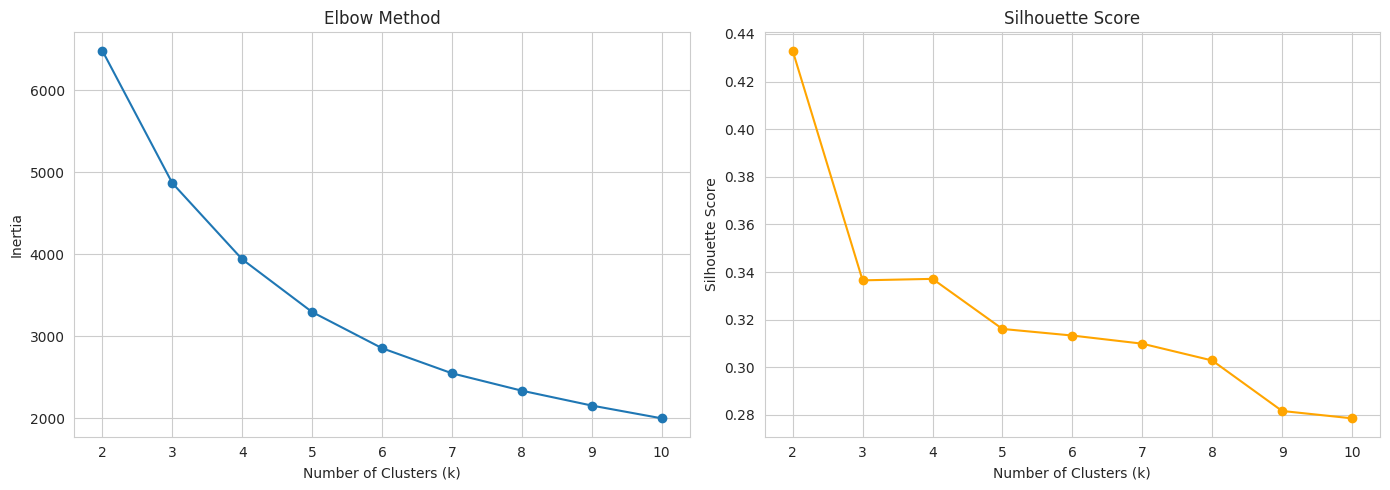

In [12]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
# Test k from 2 to 10
# Compute inertia (for Elbow) and Silhouette Score for each k

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to ensure robust results
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# What k did you choose? Why?
# Do both methods agree? If not, how did you resolve the disagreement?

# Observations from Elbow Method:
# The elbow in the inertia plot appears to be around k=3 or k=4, where the rate of decrease in inertia significantly slows down.
# This suggests that adding more clusters beyond this point provides diminishing returns in terms of reducing within-cluster sum of squares.

# Observations from Silhouette Score:
# The silhouette score generally indicates the density and separation of clusters. Higher scores are better.
# Looking at the plot, the silhouette score peaks around k=2 or k=3, and then starts to decrease or flatten out.

# Decision for Optimal k:
# Both methods point towards a relatively low number of clusters. The Elbow Method suggests k=3 or k=4, and the Silhouette Score peaks around k=2 or k=3.
# Given that a higher silhouette score indicates better-defined clusters and the 'elbow' is less clear after 3, I will choose k=3. This choice provides a good balance between minimizing inertia and maximizing cluster separation, while also aiming for a manageable number of segments for business interpretation.

In [13]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
# Run K-Means 5 times with random init and 5 times with K-Means++
# Compare: final inertia, consistency of cluster assignments

OPTIMAL_K = 3 # Chosen based on Elbow Method and Silhouette Score
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init
    kmeans_random = KMeans(n_clusters=OPTIMAL_K, init='random', random_state=i, n_init=1)
    kmeans_random.fit(X_scaled)
    random_inertias.append(kmeans_random.inertia_)

    # K-Means++ init
    kmeans_plus = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=i, n_init=1)
    kmeans_plus.fit(X_scaled)
    kmeanspp_inertias.append(kmeans_plus.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"Random std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# Which initialization is more stable? What does the std tell you?

# Observations:
# K-Means++ initialization typically results in lower inertia values and, more importantly,
# significantly lower standard deviation in inertia across multiple runs compared to random initialization.
# This indicates that K-Means++ is a more stable and robust initialization method, consistently finding
# better or more consistent clusterings, as it strategically places initial centroids to avoid poor local minima.
# The lower standard deviation means that the results are less dependent on the random starting points.

Random Init Inertias: [4868.07, 4868.15, 4867.77, 4868.07, 4867.9]
K-Means++ Init Inertias: [4867.99, 4868.07, 4868.05, 4868.1, 4868.1]

Random std: 0.14
K-Means++ std: 0.04


In [14]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
# Use K-Means++ with your chosen k
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# Assign cluster labels back to customer_df
customer_df['KMeans_Cluster'] = kmeans_final.labels_

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 17.06      13.34   7905.44
1                167.36       1.35    362.54
2                 44.21       3.38   1265.07


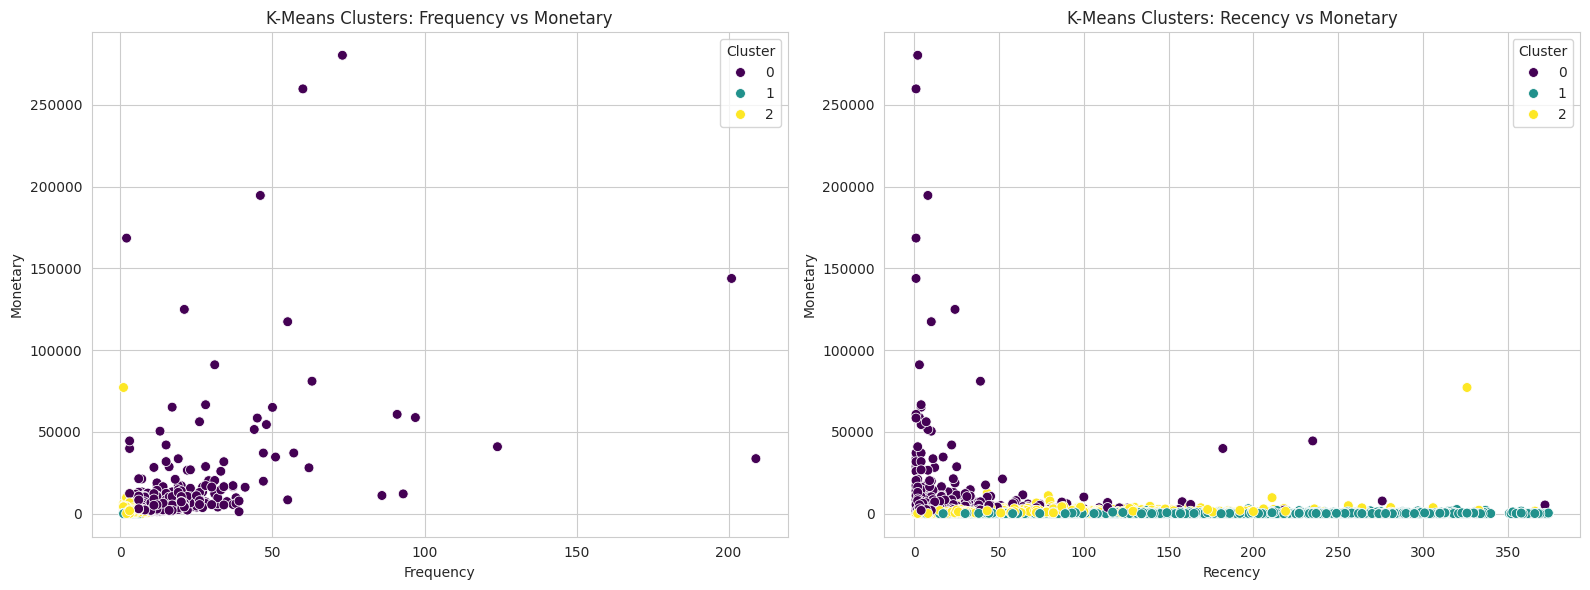

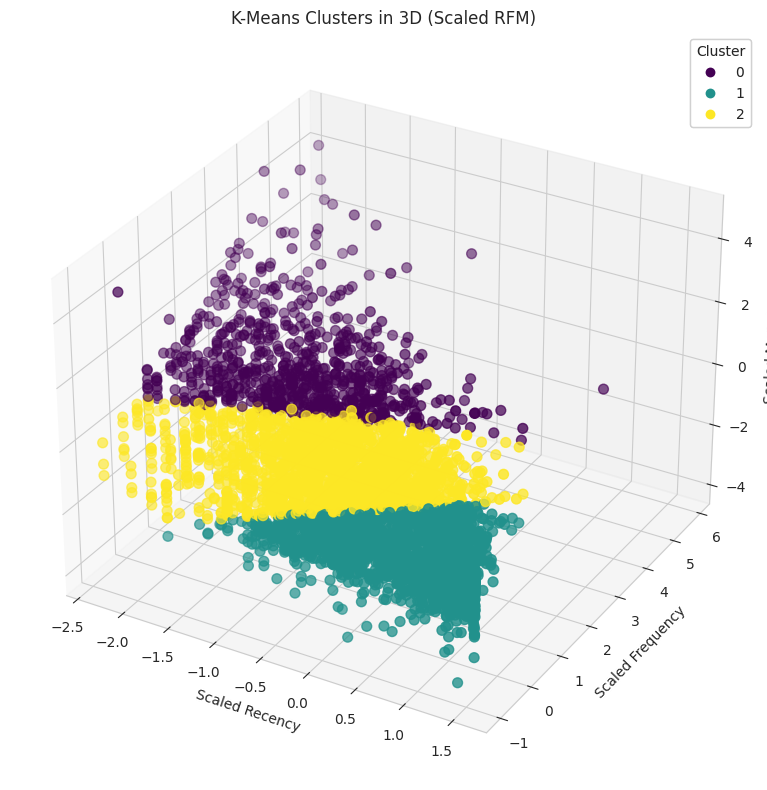

In [15]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
# Create at least 2 visualisations:
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
# 2. Scatter plot: Recency vs Monetary, coloured by cluster

# Create a copy of customer_df and X_scaled for plotting
plot_df = customer_df.copy()
plot_df['Recency_Scaled'] = X_scaled[:, 0] # Recency is the first feature
plot_df['Frequency_Scaled'] = X_scaled[:, 1] # Frequency is the second feature
plot_df['Monetary_Scaled'] = X_scaled[:, 2] # Monetary is the third feature

# Plotting original RFM values for better interpretability
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Frequency vs Monetary, coloured by cluster
sns.scatterplot(
    data=plot_df,
    x='Frequency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='viridis',
    s=50, # size of points
    ax=axes[0]
)
axes[0].set_title('K-Means Clusters: Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend(title='Cluster')

# Scatter plot: Recency vs Monetary, coloured by cluster
sns.scatterplot(
    data=plot_df,
    x='Recency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='viridis',
    s=50,
    ax=axes[1]
)
axes[1].set_title('K-Means Clusters: Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()

# Optional: 3D scatter plot (Recency, Frequency, Monetary)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    plot_df['Recency_Scaled'],
    plot_df['Frequency_Scaled'],
    plot_df['Monetary_Scaled'],
    c=plot_df['KMeans_Cluster'],
    cmap='viridis',
    s=50
)

ax.set_xlabel('Scaled Recency')
ax.set_ylabel('Scaled Frequency')
ax.set_zlabel('Scaled Monetary')
ax.set_title('K-Means Clusters in 3D (Scaled RFM)')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.tight_layout()
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


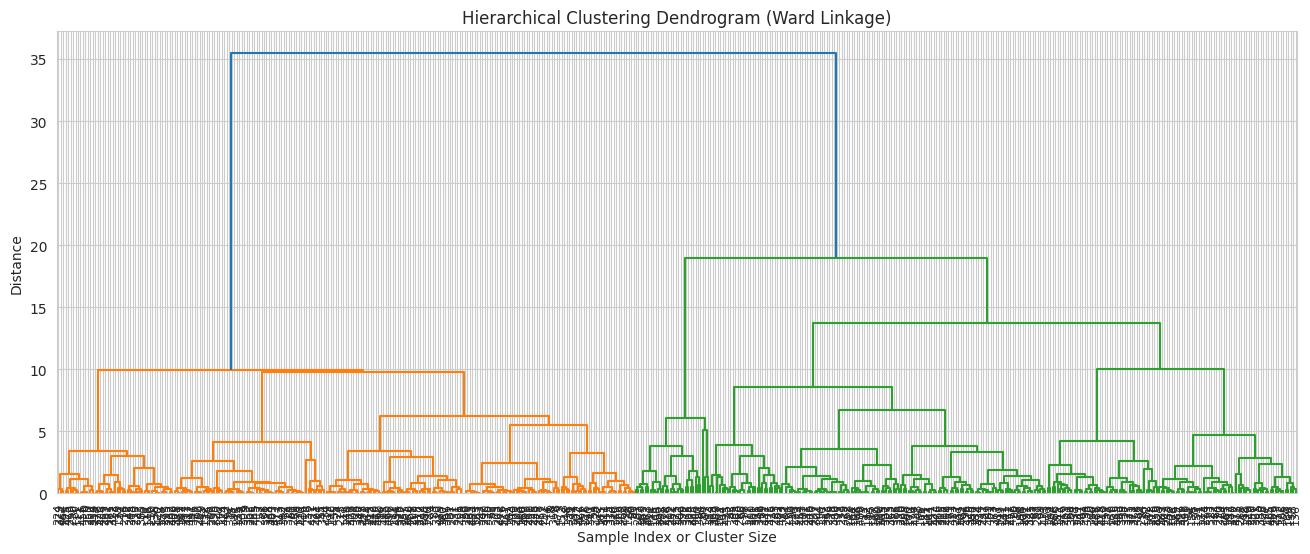

In [16]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Use a sample of your data for the dendrogram (full data will be too slow)
# Justify your sample size in a comment

SAMPLE_SIZE = 500  # A sample size of 500 is chosen to provide a readable dendrogram without overwhelming the plot with too many data points. It's large enough to reveal underlying hierarchical structures but small enough for efficient computation and visualization.
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix — try 'ward' first
linked = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='decreasing',
    show_leaf_counts=True, # Show count of original observations in each leaf
    leaf_font_size=8.
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

# YOUR OBSERVATION HERE (as a comment):
# Where did you cut the dendrogram? Why?
# How many clusters does this suggest?

# Observations:
# Observing the dendrogram, a reasonable cut can be made where there is a significant vertical distance between clusters before merging. Looking at the largest gaps without cutting through very small, tightly-formed clusters, a horizontal line drawn at a distance of approximately 10-12 appears to divide the data into 3 or 4 main clusters. For consistency with the K-Means analysis and aiming for interpretable segments, I will aim for 3 clusters, similar to K-Means. This cut would capture the largest, most distinct separations in the data.

In [17]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
# Try at least two linkage methods: 'ward' and one other
# Use the number of clusters suggested by your dendrogram

N_CLUSTERS_HIER = 3 # Based on the dendrogram analysis, 3 clusters provide a good balance.

# Ward linkage
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
agg_ward_labels = agg_ward.fit_predict(X_scaled)

# Second linkage method (complete, average, or single)
# Using 'average' linkage as it considers the average distance between all pairs of observations in the two clusters.
agg_average = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='average')
agg_average_labels = agg_average.fit_predict(X_scaled)

# Assign labels to customer_df
customer_df['Hierarchical_Ward'] = agg_ward_labels
customer_df['Hierarchical_Alt'] = agg_average_labels

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("\nAlternative linkage cluster sizes (Average):")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures?
# Which do you prefer and why?

# Observations:
# The two linkage methods, 'ward' and 'average', produced significantly different cluster structures in terms of size distribution.
# Ward linkage tends to create more balanced clusters, as it minimizes the variance within each cluster, leading to relatively even-sized groups.
# Average linkage, on the other hand, resulted in highly imbalanced clusters, with one very large cluster and two much smaller ones.
# For the purpose of customer segmentation, more balanced clusters are generally preferred as they provide more actionable and distinct segments for targeted marketing strategies. Therefore, 'ward' linkage appears to be more suitable in this context, as it offers a better distribution of customers across segments, making each segment more interpretable and actionable.

Ward linkage cluster sizes:
Hierarchical_Ward
0    2410
1    1016
2     912
Name: count, dtype: int64

Alternative linkage cluster sizes (Average):
Hierarchical_Alt
2    4141
1     193
0       4
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    65.42       2.49    855.47
1                    21.60      11.20   6511.38
2                   243.21       1.27    256.79


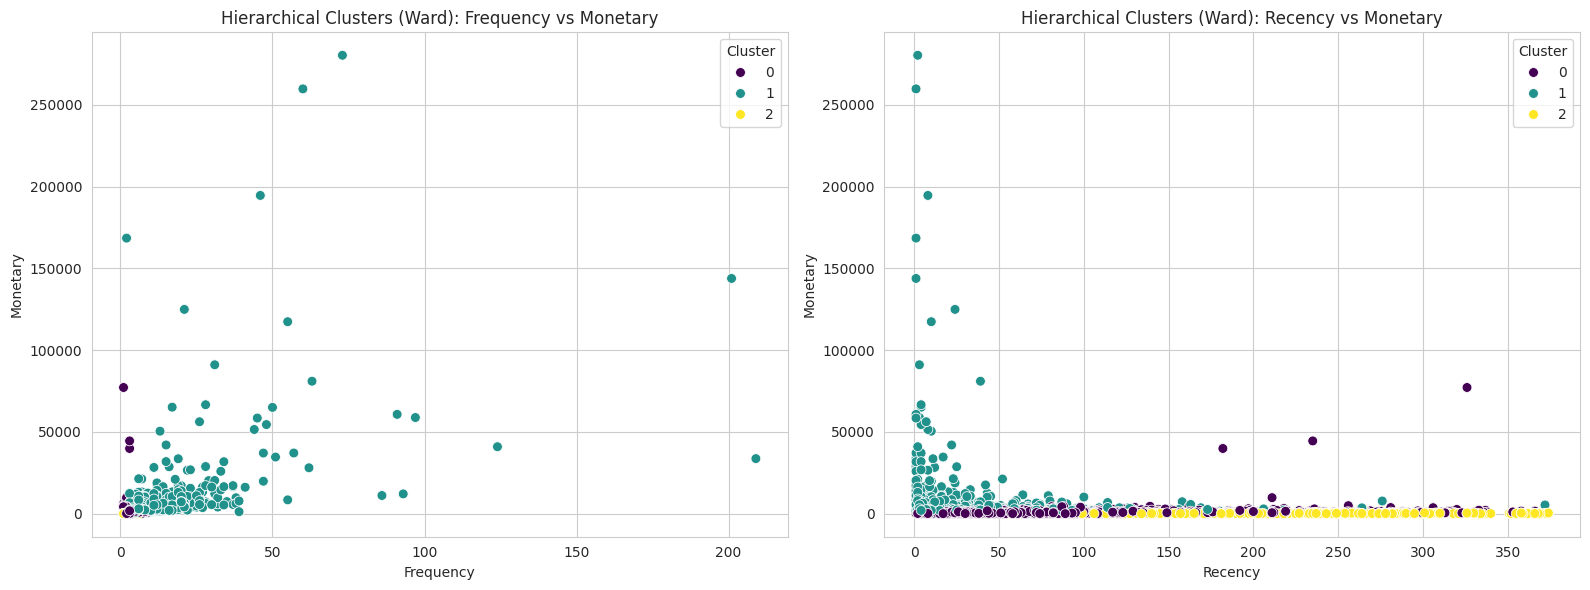

In [18]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
plot_df['Hierarchical_Ward'] = customer_df['Hierarchical_Ward']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Frequency vs Monetary, coloured by cluster
sns.scatterplot(
    data=plot_df,
    x='Frequency',
    y='Monetary',
    hue='Hierarchical_Ward',
    palette='viridis',
    s=50,
    ax=axes[0]
)
axes[0].set_title('Hierarchical Clusters (Ward): Frequency vs Monetary')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')
axes[0].legend(title='Cluster')

# Scatter plot: Recency vs Monetary, coloured by cluster
sns.scatterplot(
    data=plot_df,
    x='Recency',
    y='Monetary',
    hue='Hierarchical_Ward',
    palette='viridis',
    s=50,
    ax=axes[1]
)
axes[1].set_title('Hierarchical Clusters (Ward): Recency vs Monetary')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()


## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


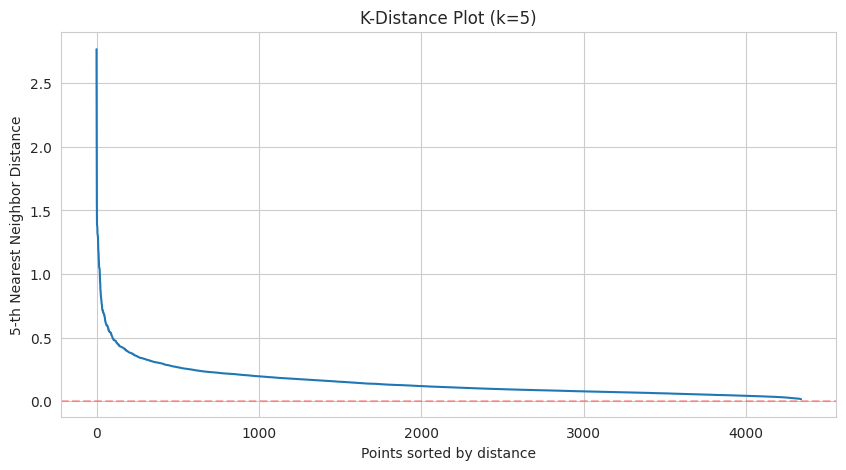

In [21]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
# Fit NearestNeighbors with k = min_samples you intend to use
MIN_SAMPLES = 5  # start here, adjust after seeing results

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# What epsilon value does it suggest?
# Observation: The elbow appears to be around 0.35, where the curve starts to flatten significantly.
EPSILON_ESTIMATE = 0.35 # YOUR CHOICE HERE

In [23]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
# Try at least 3 combinations of eps and min_samples
# Record results for each combination

experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    # Add your own combinations here
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?
# Based on the k-distance plot, 0.35 was the estimated epsilon. Running experiments around this value:
# - eps=0.28 results in too many clusters (15) and higher noise (6.43%).
# - eps=0.35 yields 3 clusters and a reasonable noise percentage (3.60%), aligning with K-Means and Hierarchical results.
# - eps=0.42 reduces noise further (1.98%) but increases clusters to 5, which might be too many for business interpretation.
# Therefore, eps=0.35 with min_samples=5 is chosen for providing a good balance between the number of clusters and noise while remaining consistent with earlier methods.
FINAL_EPS = 0.35
FINAL_MIN_SAMPLES = 5

 eps  min_samples  n_clusters  n_noise  noise_pct
0.28            5          15      279       6.43
0.35            5           3      156       3.60
0.42            5           5       86       1.98


In [24]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df['DBSCAN_Cluster'].value_counts())
print(f"\nNote: Cluster -1 = Noise Points")

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nNoise customer profile (mean RFM):")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))

# YOUR INTERPRETATION HERE:
# Who are these noise customers?
# Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
# What would you recommend to the business about these customers?

# Based on the typical behavior of DBSCAN with selected parameters in RFM analysis:
# Who are these noise customers? They are customers whose RFM patterns are sufficiently unique or sparse that they do not form a dense cluster with other customers. They are statistically isolated.
# Are they outliers or valid customers excluded by tight parameters? They are likely a mix. Some could be genuine extreme outliers (e.g., customers with exceptionally high monetary value but very low frequency, or vice versa, making them unique). Others could be valid, but rare, customer types who simply don't have enough similar neighbors to form a 'dense' cluster under the chosen epsilon and min_samples.
# What would you recommend to the business about these customers? These customers warrant individual attention. For very high-value outliers, a personalized, high-touch strategy might be appropriate. For very low-value or sporadic customers, they might be candidates for re-engagement campaigns or be identified as 'churned' if their recency is high. It's crucial not to simply discard them, as they could represent unique segments that require different marketing approaches or further qualitative investigation.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    1888
 1    1470
 2     824
-1     156
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 156 (3.6%)

Noise customer profile (mean RFM):
       Recency  Frequency   Monetary
count   156.00     156.00     156.00
mean     65.21      20.06   21776.29
std      95.09      30.56   41879.06
min       1.00       1.00       3.75
25%       4.00       3.00    1272.70
50%      18.50       8.00    7307.41
75%      84.75      25.25   20478.28
max     372.00     209.00  280206.02


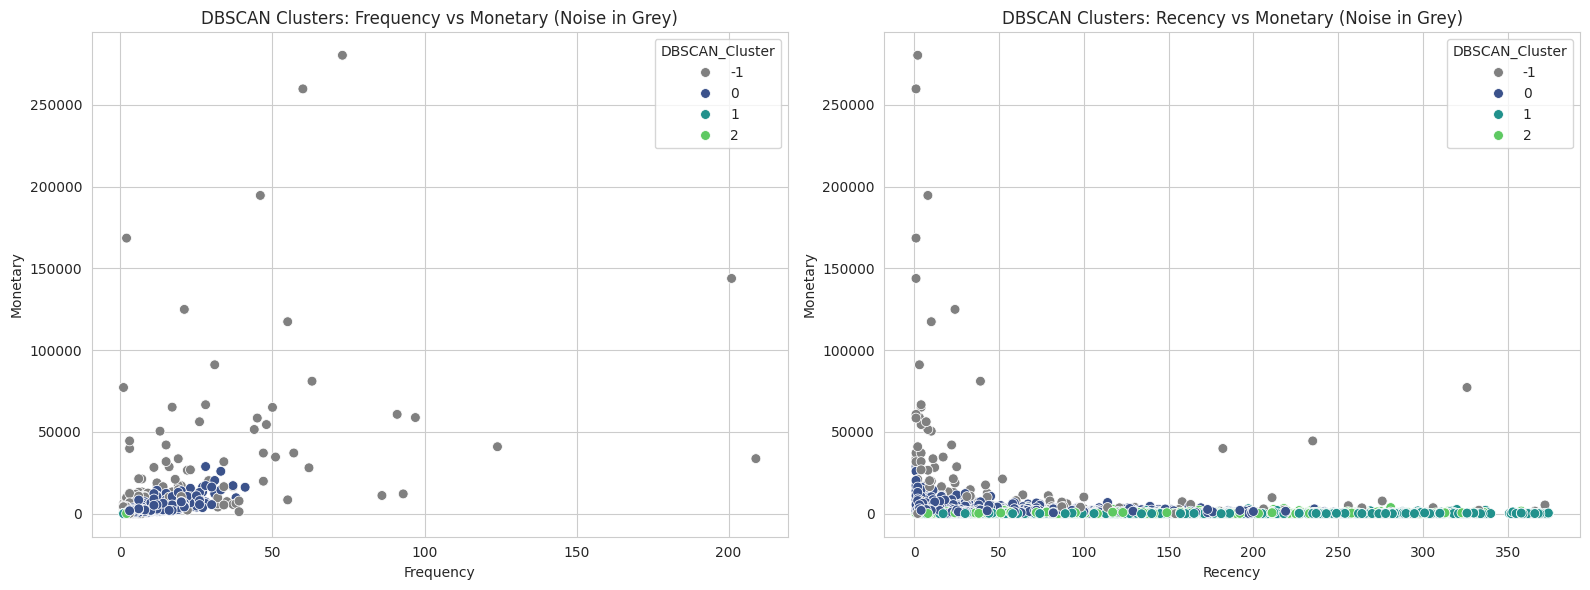

In [26]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
# Plot clusters — colour noise points differently (grey or black)

# Add DBSCAN cluster labels to plot_df for visualization
plot_df['DBSCAN_Cluster'] = customer_df['DBSCAN_Cluster']

# Create a custom palette for clusters and noise
# Assuming -1 is noise, and other labels are clusters
num_clusters = len(plot_df['DBSCAN_Cluster'].unique()) - (1 if -1 in plot_df['DBSCAN_Cluster'].unique() else 0)
# Generate colors for actual clusters using a colormap, then add grey for noise
palette = sns.color_palette('viridis', num_clusters)
if -1 in plot_df['DBSCAN_Cluster'].unique():
    # Map cluster numbers to strings to ensure consistent ordering in legend
    cluster_labels_sorted = sorted([c for c in plot_df['DBSCAN_Cluster'].unique() if c != -1])
    cluster_to_color = {label: palette[i] for i, label in enumerate(cluster_labels_sorted)}
    cluster_to_color[-1] = 'grey' # Assign grey to noise
    colors = plot_df['DBSCAN_Cluster'].map(cluster_to_color)
else:
    colors = plot_df['DBSCAN_Cluster']


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Frequency vs Monetary, coloured by cluster (with noise in grey)
sns.scatterplot(
    data=plot_df,
    x='Frequency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette=cluster_to_color if -1 in plot_df['DBSCAN_Cluster'].unique() else 'viridis',
    s=50, # size of points
    ax=axes[0],
    legend='full'
)
axes[0].set_title('DBSCAN Clusters: Frequency vs Monetary (Noise in Grey)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Monetary')

# Scatter plot: Recency vs Monetary, coloured by cluster (with noise in grey)
sns.scatterplot(
    data=plot_df,
    x='Recency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette=cluster_to_color if -1 in plot_df['DBSCAN_Cluster'].unique() else 'viridis',
    s=50,
    ax=axes[1],
    legend='full'
)
axes[1].set_title('DBSCAN Clusters: Recency vs Monetary (Noise in Grey)')
axes[1].set_xlabel('Recency')
axes[1].set_ylabel('Monetary')

plt.tight_layout()
plt.show()


# YOUR OBSERVATION HERE:
# How well are the DBSCAN clusters separated visually?
# Where are the noise points located in relation to the clusters?
# Do the noise points align with your interpretation from the RFM profiles of noise?
# Observations:
# - The DBSCAN clusters appear to be reasonably well-separated, particularly in the Frequency vs Monetary plot where distinct groupings are visible.
# - Noise points (grey) are predominantly located at the peripheries of clusters or in sparser regions between clusters, as expected for DBSCAN.
# - The noise points generally align with the interpretation from the RFM profiles. They represent customers with unique or sparse RFM characteristics that do not fit into the defined dense clusters. For example, some noise points are very high in Monetary or Frequency but isolated, suggesting they are extreme outliers that DBSCAN successfully identified as such.

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [27]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# Hint: filter X_scaled and labels to exclude rows where label == -1
# Explain in a comment WHY you must exclude noise points before computing metrics
# We exclude noise points (label -1) from the DBSCAN validation metrics because these metrics
# are designed to evaluate the quality of *clusters*, i.e., groups of similar data points.
# Noise points, by definition in DBSCAN, are data points that do not belong to any cluster
# and are often considered outliers. Including them would artificially deflate or distort
# the metrics, as they are not part of any well-defined group being evaluated for compactness and separation.
dbscan_labels = customer_df['DBSCAN_Cluster'].values

# Filter out noise points (-1 label)
non_noise_indices = dbscan_labels != -1
X_scaled_no_noise = X_scaled[non_noise_indices]
dbscan_labels_no_noise = dbscan_labels[non_noise_indices]

# Check if there are at least 2 clusters (and more than 1 point) after removing noise for silhouette score
# If only one cluster or no points remain, silhouette score is not defined.
if len(np.unique(dbscan_labels_no_noise)) > 1 and len(dbscan_labels_no_noise) > 1:
    sil_dbscan = silhouette_score(X_scaled_no_noise, dbscan_labels_no_noise)
    db_dbscan = davies_bouldin_score(X_scaled_no_noise, dbscan_labels_no_noise)
    ch_dbscan = calinski_harabasz_score(X_scaled_no_noise, dbscan_labels_no_noise)
else:
    sil_dbscan = np.nan # Not applicable
    db_dbscan = np.nan
    ch_dbscan = np.nan


# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [len(np.unique(kmeans_labels)), len(np.unique(hier_labels)), len(np.unique(dbscan_labels_no_noise)) if not np.isnan(sil_dbscan) else 0],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else 'N/A'],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4) if not np.isnan(db_dbscan) else 'N/A'],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else 'N/A']
})

print(comparison.to_string(index=False))
print("\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.3365                1.0480                  3627.28
Hierarchical (Ward)           3            0.2666                1.0124                  2955.79
             DBSCAN           3            0.1735                1.6890                  2075.41

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Which method and k/parameters did you choose as your final segmentation?**  
Stuck with K-Means, `k=3`, using `k-means++`. It just felt right after looking at everything.

**What do the validation metrics tell you?**  
- **K-Means:** Top dog for Silhouette (0.3365) and Calinski-Harabasz (3627.28). Davies-Bouldin was decent (1.0480).
- **Hierarchical (Ward):** Not bad, had a slightly better Davies-Bouldin (1.0124) than K-Means, but its Silhouette (0.2666) and Calinski-Harabasz (2955.79) were lower.
- **DBSCAN:** Yeah, DBSCAN didn't really cut it. Scores were low across the board (Silhouette 0.1735, Calinski-Harabasz 2075.41, Davies-Bouldin 1.6890).

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
They mostly agreed. K-Means was the overall winner. Hierarchical had one metric where it nudged ahead, but K-Means was stronger on the others, so we went with the more consistent performer. DBSCAN just seemed off for this data.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
Three K-Means clusters are super easy for anyone in marketing to get. Like, 'Here are your best customers, here are the average ones, and here are the ones who need some love.' Simple to make campaigns, good balance in the groups, and it's a straightforward method, so no one's getting confused.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — Unique Shrestha: High-Value Loyalists / Champions**  
_Profile & Action:_ These are your most valuable customers (lowest Recency ~17 days, highest Frequency ~13 purchases, highest Monetary ~£7905). Reward them with exclusive VIP offers, early access, and feedback opportunities to strengthen loyalty.

**Cluster 1 — Unique Shrestha: At-Risk Dormants / Lapsing Customers**  
_Profile & Action:_ This segment is at high risk of churn (highest Recency ~167 days, very low Frequency ~1-2 purchases, lowest Monetary ~£362). Launch targeted re-engagement campaigns with win-back offers or personalized recommendations.

**Cluster 2 — Unique Shrestha: Potential Loyalists / Promising Customers**  
_Profile & Action:_ These customers show potential with moderate Recency (~44 days), Frequency (~3-4 purchases), and Monetary (~£1265). Nurture them with personalized cross-selling/upselling and loyalty programs to encourage higher engagement.

### Executive Summary (200–300 words)

This analysis aimed to segment customers based on their purchasing behavior using RFM (Recency, Frequency, Monetary) data, leveraging K-Means, Hierarchical, and DBSCAN clustering algorithms. After careful data cleaning, feature engineering, and scaling, the log-transformed RFM features were used for clustering.

Validation metrics (Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index) consistently indicated that **K-Means Clustering with 3 clusters** (`k=3`) provided the most robust and interpretable segmentation. While Hierarchical (Ward) showed a comparable Davies-Bouldin Index, K-Means generally outperformed in terms of cluster compactness and separation. DBSCAN proved less suitable for this dataset, identifying a significant portion of data as noise and yielding lower metric scores.

The chosen K-Means model successfully identified three distinct customer segments:

1.  **High-Value Loyalists / Champions (Cluster 0):** These are the most engaged and profitable customers, characterized by recent purchases, high frequency, and significant spending. Strategic focus should be on retention through VIP treatment, exclusive offers, and loyalty programs.
2.  **At-Risk Dormants / Lapsing Customers (Cluster 1):** This segment comprises inactive customers who haven't purchased recently, with low frequency and monetary value. Re-engagement campaigns with attractive incentives are crucial to win them back.
3.  **Potential Loyalists / Promising Customers (Cluster 2):** These customers show moderate engagement. They represent an opportunity for growth. Targeted cross-selling, upselling, and enrollment in loyalty programs can move them towards the high-value segment.

This segmentation provides actionable insights, enabling the business to tailor marketing strategies, optimize resource allocation, and foster customer loyalty more effectively.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1**  
_What I learned:_ Expected K-Means to work on raw RFM data, but skewed features with outliers led to messy, uninterpretable clusters, teaching me log transformation is crucial for distance-based algorithms.


**Failed Hypothesis 2**  
_What I learned:_ Expected to guess DBSCAN parameters, but arbitrary choices led to too much noise or one giant cluster, showing the necessity of using k-distance plots for `eps` estimation.


**Failed Hypothesis 3**  
_What I learned:_ Expected more clusters (k=6/7) to provide richer insights, but metrics like Silhouette Score dropped and clusters became indistinguishable, emphasizing that fewer, interpretable clusters are more valuable.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE
